# 01 - The Frame Buffer and Layering

In *Magrathea*, the frame buffer is the digital canvas where each frame of our animation comes to life, much like the pixel grids James Blinn used to craft the iconic Voyager flyby animations. This section introduces the frame buffer’s role and how we use NumPy arrays to layer scene elements—planets, stars, spacecraft, and other objects—to composite a single frame, echoing Blinn’s approach to rendering.

## History
The following is all a burst of history, useful as background, but not critically important to our project. You can read it over, but if anything doesn't make sense, don't worry about it. I will explain in detail all concepts that we will use in modern terms.

Back in 1979, computers were still in their infancy. Most computers had no graphics at all. They just computed. You interacted with them through a terminal, but *only* a terminal, not like today when you can start Steam at the Linux command line and spin up a video game. A computer could calculate an image, but had trouble displaying one.

The computers that Blinn and Kohlhase worked with had some special add-on hardware to make them into graphics workstations. Much of the hardware is stuff that we now take for granted, and much of what we take for granted (like the mouse) were still missing.

Blinn's workstation had a vector display, much like an oscilliscope. It can be fed a list of points and segments to draw, and will physically move the electron beam of the CRT to trace those points. No raster scan is required. It can draw perfect diagonal lines. It can approximate curves with many short line segments. But it can't easily do filled areas. This is the hardware that Kohlhase originally used to do his line drawing plots of the fields of view during the planetary encounters.

But the magic, the feature that made the full motion video possible, is the *frame buffer*. This device had an astounding (for the time) 256KiB of memory, organized as 2,048 individual memory chips in two full server racks. This is what we would later call "video memory" in the later IBM PC. The frame buffer was attached to a color raster scan monitor, and the frame buffer had hardware that would read its memory line by line, pixel by pixel, and render a color image on its output CRT. Any change in frame buffer memory would immediately change the output.

As noted, 256KiB was an enormous amount of memory. In fact, it was larger than the whole address space of the computer it was attached to. In order to use the frame buffer, it had memory-mapped control registers and an adjustable window of memory that is swapped into the computer's address space. For instance, Blinn's PDP-11 was a 16-bit computer and could address 64KiB of memory. His had an MMU that could manage more memory, but not all at the same time. He had 128kiB, roughly organized into a low half for the operating system and a high half for his user code. In the user side was 56kiB of real memory, and an 8kiB window into 8kiB of the 256KiB of the frame buffer memory. Blinn's code had to carefully manipulate the window to reach all parts of the image to be drawn. It might go something like this:

* Use the memory-mapped registers to access the first 8KiB of frame buffer memory. This might represent the first sixteen 512-pixel lines of the image
* Calculate the first sixteen lines of the image
* Write the results of the calculation to the right part of memory, starting at 0xE000. Whatever value is written at 0xE000 will *immediately* cause the frame buffer to color the top left pixel that color. Whatever value is written at 0xE001 will *immediately* cause the frame buffer hardware to color the *next* pixel that color, and so on across all of the first four lines.
* When those first 16 lines are finished, use the memory-mapped registers to access the next 8KiB for lines 16-31. Because we have changed the memory window, when the computer writes to 0xE000, it won't be to the first pixel in line 0, but now the first pixel in line 16. The data in lines 0-15 are still in the frame buffer memory, but the computer can't see it all at the same time. The computer calcualtes the next 16 lines of the image, then writes those to the frame buffer, etc.
* If you change the window back to another section of the frame buffer that you wrote to previously, you again have access. You can write, but also read. This allows interesting effects -- you can render transparency by reading out the old color, combining it with the new color, and writing it back.

The frame buffer that was used was palette-based. Modern systems use 24-bit color, with 8 bits for red, green, and blue. Blinn's system used 16-bit color, with 5 bits for red, 6 for green, and 5 for blue. But, using 16 bits for each pixel was too much -- it would have required twice the memory, 512KiB, or two *more* racks crammed to the gills with 2,048 memory chips each. So the frame buffer had a palette -- a table of 256 entries. Each entry was 16 bits. The pixel value in the frame buffer was used to look up the color in the palette, and then that palette entry was converted to an RGB signal for that pixel.

One of the interesting things about the frame buffer is that the operating system didn't know nor care about it. Resetting the computer or running a new program would *not* reset the frame buffer. That would continue to hold whatever image was in the buffer until the next program changed it. Taking advantage of this, Blinn used a pipeline of programs, each of which drew a layer of the image from back to front:
* Stars
* Sun
* Planet and moons, from furthest to nearest
* Spacecraft triangle mesh

There was something much like a shell script which orchestrated running each of these programs in turn. To generate an animation, the programs would be run, taking from several seconds to several minutes to calculate each frame. As each program ran, its output would appear line by line on the frame buffer, sometimes covering up previous output from previous programs. When the frame was finished, a film movie camera would be used to take a picture of the image on the CRT. The camera had appropriate optics to perfectly record the image, with proper focus, exposure, and isolation from room light. Later devices could output directly to videotape, but still a frame at a time. No computer had enough storage to hold all finished frames at once.


## Modern frame buffer

We are going to use the concept of the frame buffer in our code, but modern computers have literally millions of times as much memory as Blinn's system did. The laptop I am typing on has 32GiB of main memory, directly accessable to the CPU, aside from any video memory which is associated with the GPU and therefore out of scope for us.

We can take advantage of this enormous wealth of resources in several ways:
* All programs in memory at once. Each "program" that Blinn used, we will replicate, but as a Python function. Our script will have all the functions at once, loaded into memory and called from the `magrathea` module as needed.
* Our frame buffer is also all in memory at once. This makes it much easier to use, and NumPy will make it easier still.
* We can load all star catalogs, texture maps, spice kernels, etc into memory at once for performance.

But, we will still take advantage of the frame buffer concept to pipeline our process. Each step of the pipeline will draw one layer of the image, overwriting previous layers and perhaps being overwritten in turn by later layers. Each step is a Python function, and one of the parameters it will take is the reference to the frame buffer. The function will change the frame buffer values. Then the next function will get a reference to that same array, which will remember the values from previous functions.

### Numpy
In Blinn’s era, frame buffers were hardware-constrained, often limited to low resolutions and color depths. *Magrathea* uses NumPy arrays to emulate this concept, leveraging modern computing power while preserving the simplicity of Blinn’s pipeline.

For our purposes, the frame buffer is a 3D array that stores pixel data for a single frame, of shape (H,W,3). typically representing color values (e.g., RGB or RGBA) for each pixel on the screen. The first dimension is the row number, the second is the column number, and the third is the red (0), green (1), or blue (2) component. We could do it any way we wanted, but if we organize our images this way, they match the convention used by `matplotlib` and `pillow` for displaying and saving the images.

For a frame buffer with a resolution of 1920x1080 pixels and RGB color (red, green, blue), we define it as a NumPy array:

In [2]:
import numpy as np

# Initialize a frame buffer
width, height = 640,480
frame_buffer = np.zeros((height, width, 3), dtype=np.float64)


Note that there is a convention mismatch. Mathematicians have always indexed matrices with row index, then column index. This makes sense by itself, but conflicts with the convention *also* given to us by mathematicians where the horizontal coordinate x is listed before the vertical component y. This unfortunately means that the storage for pixel `(x,y)` is in `frame_buffer[y, x, :]` -- note that y and x are reversed. I hate it every time I see it, and I doubly hate it every time I type it, but I can't change conventions myself.

In order to match matplotlib and pillow, each component is intended to be a value between 0.0 and 1.0. Pure red will be `(1.0,0.0,0.0)`, blue `(0.0,0.0,1.0)`, orange is `(1.0,0.5,0.0)` etc.

## Layering Objects and the Painter's Algorithm
Blinn’s animations layered multiple elements: planets, rings, stars, and spacecraft, onto a single frame, combining them in a way that respected depth. In *Magrathea*, we achieve this by making one frame buffer and passing it in turn to each rendering function. The *painter’s algorithm* is a rendering technique that simulates depth. Named for its analogy to a painter layering brushstrokes on a canvas, this algorithm renders scene elements in a back-to-front order, ensuring that closer objects overwrite farther ones in the frame buffer. In Blinn’s pipeline, each layer -- stars, Sun, planets, moons, and spacecraft -- was rendered sequentially, with each program writing to the persistent frame buffer, overwriting previous pixels as needed. Magrathea adopts this approach using NumPy arrays, layering objects like stars and planets in a similar back-to-front sequence.

### How the Painter’s Algorithm Works
In Magrathea, the painter’s algorithm operates as follows:

* Sort Objects by Depth: Arrange scene elements (e.g., stars, Sun, planet) from farthest to nearest based on their z-coordinate or distance from the viewer.
* Render Back to Front: Render each object into the frame buffer in this order, allowing closer objects to overwrite pixels of farther ones. For example, stars are rendered first, followed by the Sun, then planets and moons, and finally the spacecraft.
* Write to Frame Buffer: Each object’s pixels are written directly to the NumPy-based frame buffer, typically using a mask to define the object’s shape (e.g., a circle for a planet).

### Example: Layering a Planet and Stars
Let’s sketch a basic example of rendering a planet and a starfield into the frame buffer. Assume we have a function to render a planet (a circle with a solid color) and a starfield (random white pixels).

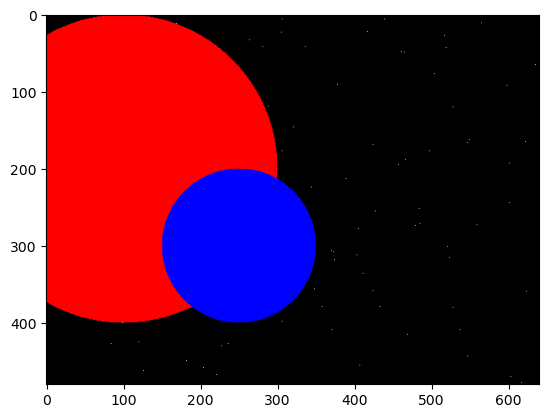

In [3]:
def stars(fb:np.ndarray,n_stars:int=10,color:np.ndarray=None):
    """
    Draw stars on the frame buffer
    :param frame_buffer: HxWx3 frame buffer
    :param n_stars: Number of stars to draw
    """
    np.random.seed(3217)
    if color is None:
        color=np.array((1.0,1.0,1.0))
    star_indices = np.random.choice(width * height, size=n_stars, replace=False)
    star_ys,star_xs=np.unravel_index(star_indices, (height, width))
    fb[star_ys,star_xs]= color


def planet(fb:np.ndarray,cx:int=100,cy:int=200,r:int=200,color:np.ndarray=None):
    """
    Draw a solid disk representing a planet
    :param frame_buffer:
    :param cx: center of planet disk
    :param cy: center of planet disk
    :param r: radius of planet disk
    :param color:
    :return:
    """
    if color is None:
        color=np.array((1.0,0.0,0.0))
    y, x = np.ogrid[:height, :width]
    mask = (x - cx) ** 2 + (y - cy) ** 2 <= r ** 2
    fb[mask,:] = color  # Red, opaque planet

import matplotlib.pyplot as plt
stars(frame_buffer,100)
planet(frame_buffer)
planet(frame_buffer,cx=250,cy=300,r=100,color=np.array((0.0,0.0,1.0)))
plt.figure("Simple composition")
plt.imshow(frame_buffer)
plt.show()

This code creates several layers: a starfield with random white stars, a red planet as a circular disk, and a blue moon that partially covers the red disk. The planet is layered over the starfield since it is painted *after* the stars. Each pixel that is in the planet disk is painted, and each pixel that is not is left its previous value. Similarly the moon is layered over both the planet and the stars, since it is painted after both.


## Output
This frame buffer is the conventional format for both display and file I/O. We can display an image using `plt.imshow()` and save it using `plt.imsave()`. These routines both convert the [0,1] range of color components to the [0,255] needed by the screen or image file format.

It might happen that our layering process ends up generating values out of this range. When this happens, we can use `np.clip()` to constrain all components to in-range. If we don't and any out of range values are present, `plt.imsave()` will generate a warning but still work, effectively applying the clip itself.

In [4]:
plt.imsave(f"output/planet_moon_stars.png",np.clip(frame_buffer,0.0,1.0))


## Animations
To do an animation, we just do multiple images. Blinn had his code render each frame then used a film camera as stated above. We will save each image to its own file, then use `ffmpeg` to combine all images into one video file. Notice that this code has no on-screen output, just files.

In [5]:
import os
import subprocess
os.makedirs('frames',exist_ok=True)
for i_frame in range(100):
    frame_buffer=np.zeros((480,640,3)) # clear out frame buffer each time
    stars(frame_buffer)
    planet(frame_buffer)
    planet(frame_buffer,cx=250+i_frame,cy=300,r=100,color=np.array((0.0,0.0,1.0)))
    plt.imsave(f"frames/frame_{i_frame:02d}.png",np.clip(frame_buffer,0.0,1.0))
subprocess.run(["ffmpeg","-i","frames/frame_%02d.png","-y","output/planet_moon_stars.mp4"])

ffmpeg version 6.1.1-3ubuntu5 Copyright (c) 2000-2023 the FFmpeg developers
  built with gcc 13 (Ubuntu 13.2.0-23ubuntu3)
  configuration: --prefix=/usr --extra-version=3ubuntu5 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --disable-omx --enable-gnutls --enable-libaom --enable-libass --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libglslang --enable-libgme --enable-libgsm --enable-libharfbuzz --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx265 --enable-libxml2 --enable-libxvid --enable-libzimg --ena

CompletedProcess(args=['ffmpeg', '-i', 'frames/frame_%02d.png', '-y', 'output/planet_moon_stars.mp4'], returncode=0)